In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from skimage import io, color, filters, transform, util

from scipy.fftpack import dct, idct

In [2]:
img_bgr = cv2.imread('./image.png')

In [3]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

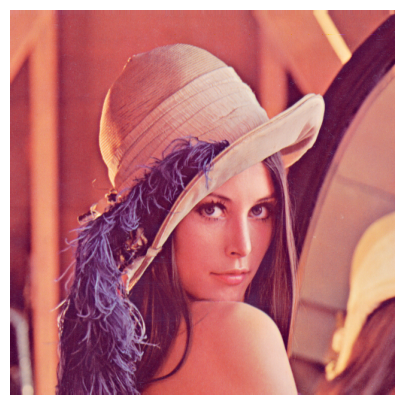

In [4]:
plt.figure(figsize=(5,5))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

In [5]:
img_ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)

In [6]:
Y, Cr, Cb = cv2.split(img_ycrcb)

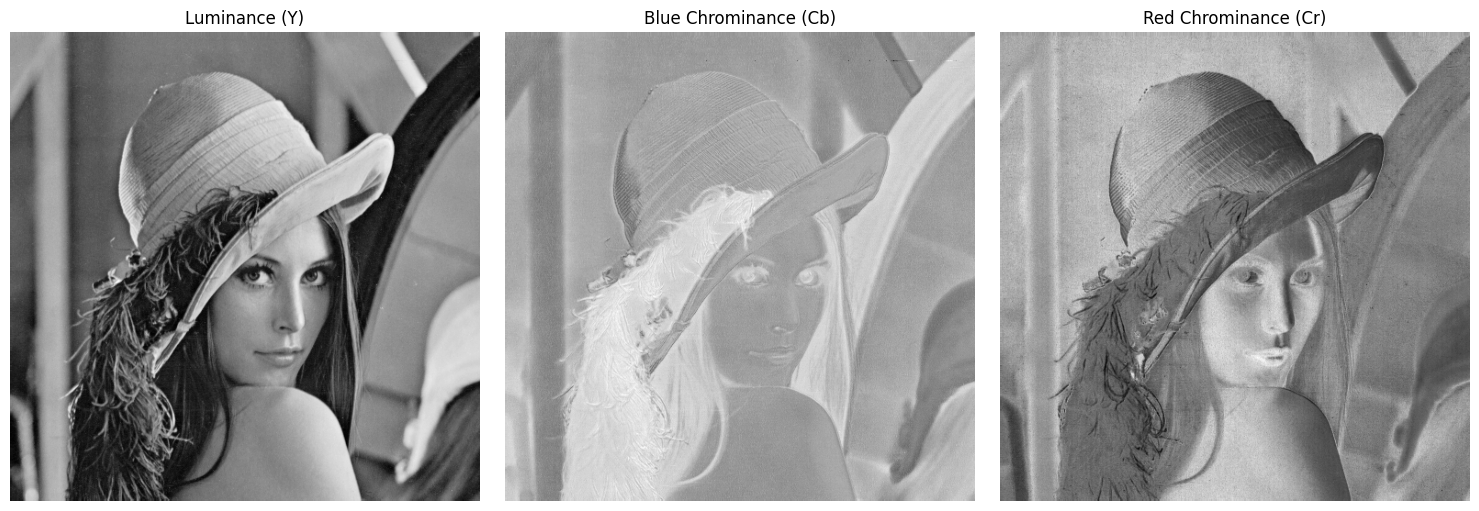

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(Y, cmap='gray')
axes[0].set_title('Luminance (Y)')
axes[0].axis('off')

axes[1].imshow(Cb, cmap='gray')
axes[1].set_title('Blue Chrominance (Cb)')
axes[1].axis('off')

axes[2].imshow(Cr, cmap='gray')
axes[2].set_title('Red Chrominance (Cr)')
axes[2].axis('off')

plt.tight_layout()
plt.show()


In [8]:
def chroma_subsample(channel):
    h, w = channel.shape
    h, w = h - h % 2, w - w % 2

    channel = channel[:h, :w]

    subsampled = np.zeros((h // 2, w // 2), dtype=np.float32)
    
    for i in range(0, h, 2):
        for j in range(0, w, 2):
            top_left     = channel[i, j]
            top_right    = channel[i, j+1]
            bottom_left  = channel[i+1, j]
            bottom_right = channel[i+1, j+1]

            average = (top_left + top_right + bottom_left + bottom_right) / 4
            
            subsampled[i//2, j//2] = average

    return subsampled.astype(np.uint8)

In [9]:
Cb_sub = chroma_subsample(Cb)
Cr_sub = chroma_subsample(Cr)

C:\Users\User\AppData\Local\Temp\ipykernel_7488\1065903909.py:16: RuntimeWarning: overflow encountered in scalar add
  average = (top_left + top_right + bottom_left + bottom_right) / 4


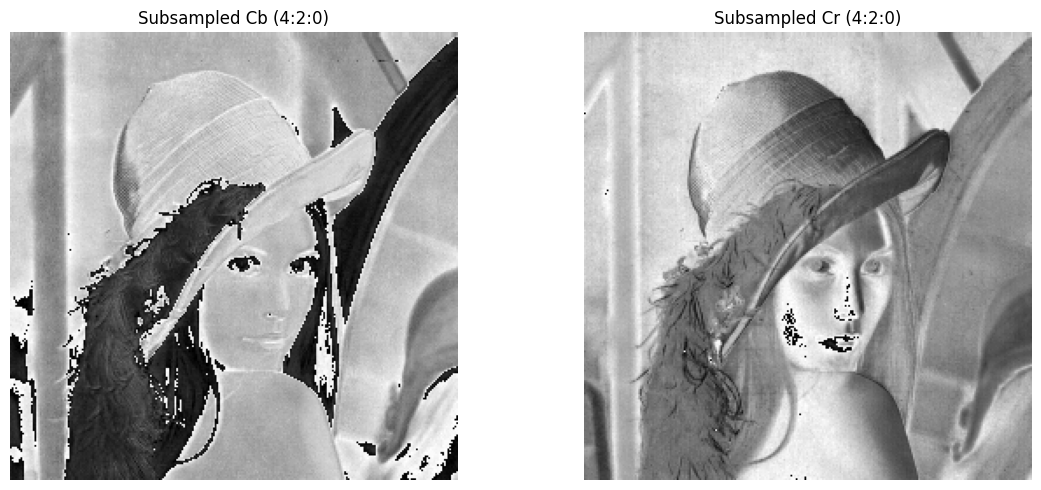

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(Cb_sub, cmap='gray')
axes[0].set_title('Subsampled Cb (4:2:0)')
axes[0].axis('off')

axes[1].imshow(Cr_sub, cmap='gray')
axes[1].set_title('Subsampled Cr (4:2:0)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [11]:
def split_into_blocks(channel, block_size=8):
    h, w = channel.shape
    h_trim = h - (h % block_size)
    w_trim = w - (w % block_size)
    channel = channel[:h_trim, :w_trim]  

    blocks = []
    for i in range(0, h_trim, block_size):
        row_blocks = []
        for j in range(0, w_trim, block_size):
            block = channel[i:i+block_size, j:j+block_size]
            row_blocks.append(block)
        blocks.append(row_blocks)

    return np.array(blocks)


In [12]:
blocks = split_into_blocks(Y, 8)

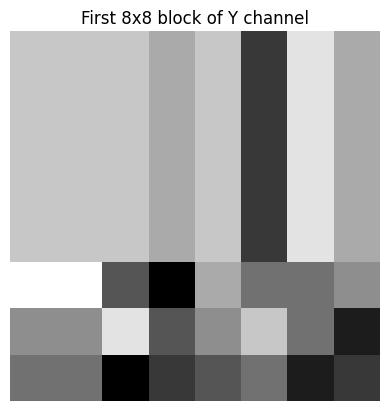

In [13]:
plt.imshow(blocks[0, 0], cmap='gray')
plt.title('First 8x8 block of Y channel')
plt.axis('off')
plt.show()

In [14]:
dct_block = dct(blocks[0, 0].astype(np.float32))

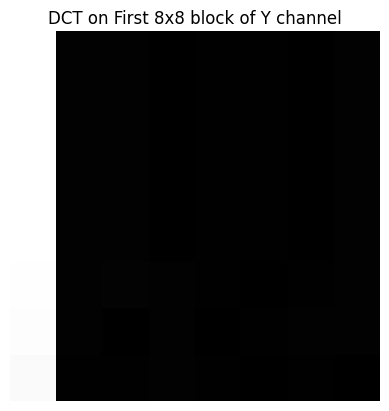

In [15]:
plt.imshow(dct_block, cmap='gray')
plt.title('DCT on First 8x8 block of Y channel')
plt.axis('off')
plt.show()